In [20]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd 

# load imag using cv2
img = cv2.imread('sweet-colorful-candies2.jpg')


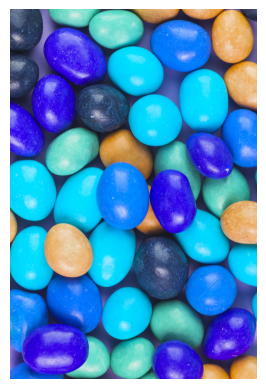

In [21]:
#original foramat
plt.imshow(img)
plt.axis('off')  
plt.show()

it's bgr 

# Visualisation de l'Image en RGB

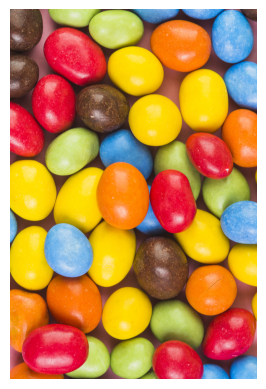

In [22]:

# Convert image to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off') 
plt.show()


# Séparation et Affichage des Canaux RGB 

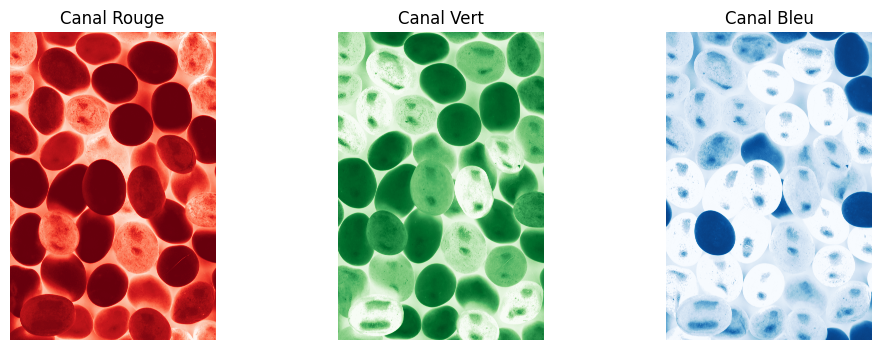

In [23]:
# Extraire les canaux individuels
R = img_rgb[:,:,0]  # Canal Rouge
G = img_rgb[:,:,1]  # Canal Vert
B = img_rgb[:,:,2]  # Canal Bleu

# Affichage des canaux
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(R, cmap='Reds')
axs[0].set_title('Canal Rouge')
axs[0].axis('off')

axs[1].imshow(G, cmap='Greens')
axs[1].set_title('Canal Vert')
axs[1].axis('off')

axs[2].imshow(B, cmap='Blues')
axs[2].set_title('Canal Bleu')
axs[2].axis('off')

plt.show()


#  Conversion en d'autres espaces de couleurs 

- -----------------------------CMY-------------------------------------

In [35]:
# Step 3: Normalize RGB values to [0, 1]
img_rgb_normalized = img_rgb / 255
img_rgb_normalized


array([[[0.50196078, 0.41176471, 0.34901961],
        [0.48235294, 0.39215686, 0.32941176],
        [0.47843137, 0.37647059, 0.3254902 ],
        ...,
        [0.59215686, 0.44313725, 0.40784314],
        [0.58431373, 0.43921569, 0.40784314],
        [0.57647059, 0.43137255, 0.4       ]],

       [[0.52941176, 0.43921569, 0.37647059],
        [0.50980392, 0.41960784, 0.35686275],
        [0.49411765, 0.39215686, 0.34117647],
        ...,
        [0.57647059, 0.42745098, 0.39215686],
        [0.58431373, 0.43529412, 0.4       ],
        [0.57647059, 0.43137255, 0.39607843]],

       [[0.49803922, 0.40784314, 0.34509804],
        [0.49019608, 0.4       , 0.3372549 ],
        [0.48627451, 0.39607843, 0.34117647],
        ...,
        [0.56862745, 0.41176471, 0.37254902],
        [0.57254902, 0.41568627, 0.37647059],
        [0.56078431, 0.41176471, 0.36862745]],

       ...,

       [[0.9254902 , 0.44705882, 0.11372549],
        [0.91372549, 0.43529412, 0.09803922],
        [0.9254902 , 0

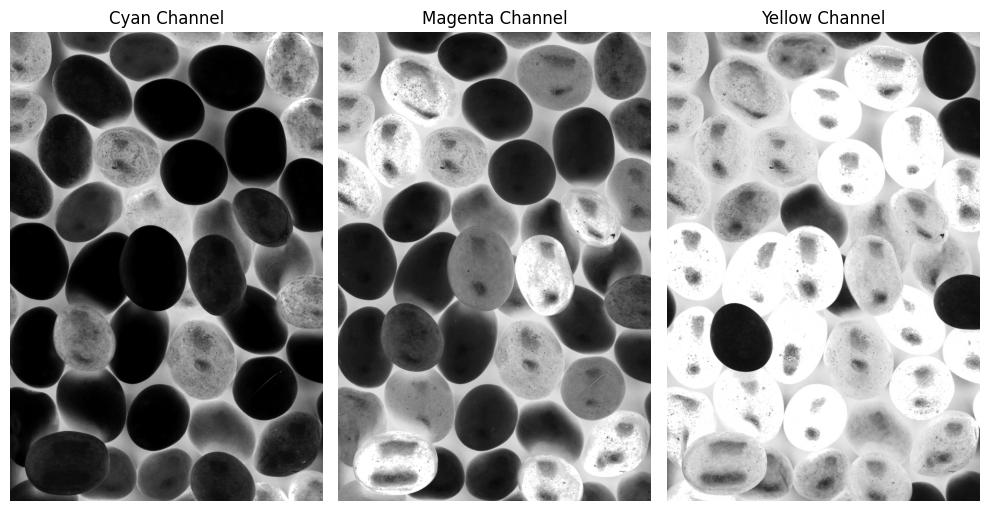

In [ ]:

import numpy as np

# Step 4: Compute CMY values
img_cmy = 1 - img_rgb_normalized

# Step 5: Scale CMY values back to [0, 255] for visualization
img_cmy_255 = (img_cmy * 255)

# Split CMY channels
C, M, Y = cv2.split(img_cmy_255)

# Display the CMY channels
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.title("Cyan Channel")
plt.imshow(C, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Magenta Channel")
plt.imshow(M, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Yellow Channel")
plt.imshow(Y, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


- HSV

- Manually

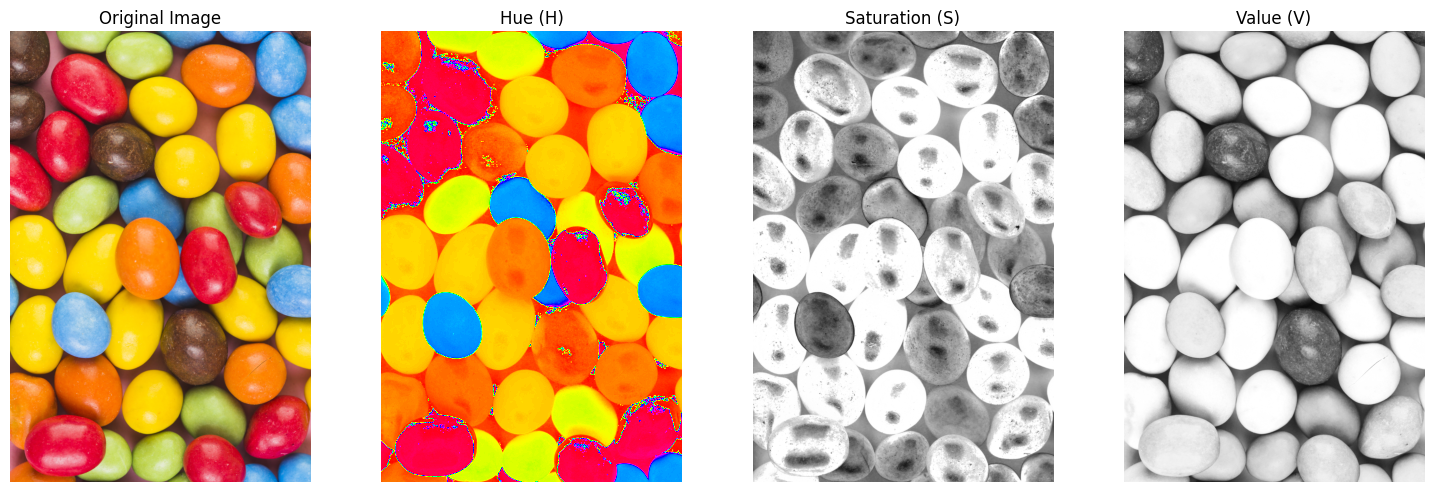

In [60]:

# Normalize RGB values to [0, 1]
R_prime = img_rgb[:, :, 0] / 255
G_prime = img_rgb[:, :, 1] / 255
B_prime = img_rgb[:, :, 2] / 255

# Calculate C_max, C_min, and Delta
C_max = np.max(img_rgb / 255, axis=2)  # Max of R, G, B
C_min = np.min(img_rgb / 255, axis=2)  # Min of R, G, B
Delta = C_max - C_min  # Difference between max and min

# Value (V)
V = C_max

# Compute Saturation (S)
S = np.where(C_max != 0, Delta / C_max, 0)

# Compute Hue (H)
H = np.zeros_like(C_max)  # Initialize H as zeros

# Case when C_max is R'
mask_r = (C_max == R_prime) & (Delta != 0)
H[mask_r] = (60 * ((G_prime[mask_r] - B_prime[mask_r]) / Delta[mask_r]) + 360) % 360

# Case when C_max is G'
mask_g = (C_max == G_prime) & (Delta != 0)
H[mask_g] = (60 * ((B_prime[mask_g] - R_prime[mask_g]) / Delta[mask_g]) + 120) % 360

# Case when C_max is B'
mask_b = (C_max == B_prime) & (Delta != 0)
H[mask_b] = (60 * ((R_prime[mask_b] - G_prime[mask_b]) / Delta[mask_b]) + 240) % 360

# Step 7: Scale H, S, and V to OpenCV ranges
H = H / 2  # Scale H to [0, 179]
S = S * 255  # Scale S to [0, 255]
V = V * 255  # Scale V to [0, 255]

# Step 8: Merge the H, S, V channels
img_hsv_manual = cv2.merge([H, S, V])

# Step 9: Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Hue (H)")
plt.imshow(H, cmap='hsv')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Saturation (S)")
plt.imshow(S, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Value (V)")
plt.imshow(V, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


- CV2

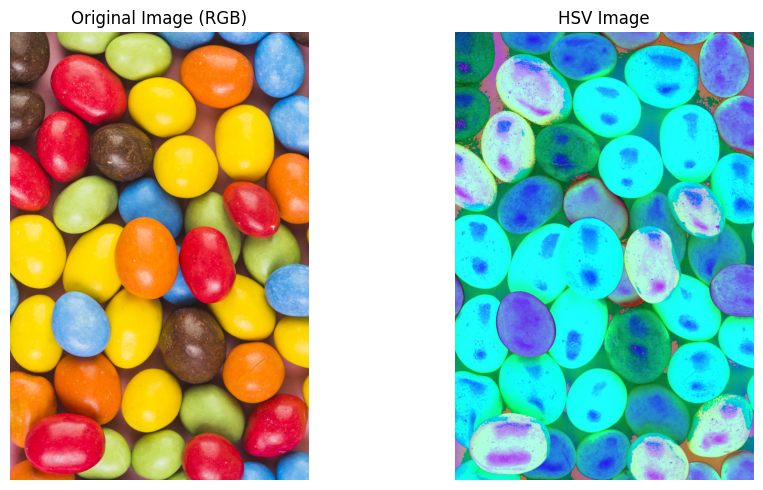

In [37]:
# Convert the image to HSV using cv2.COLOR_RGB2HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Display the original image and the HSV image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image (RGB)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_hsv)
plt.title("HSV Image")
plt.axis('off')

plt.tight_layout()
plt.show()

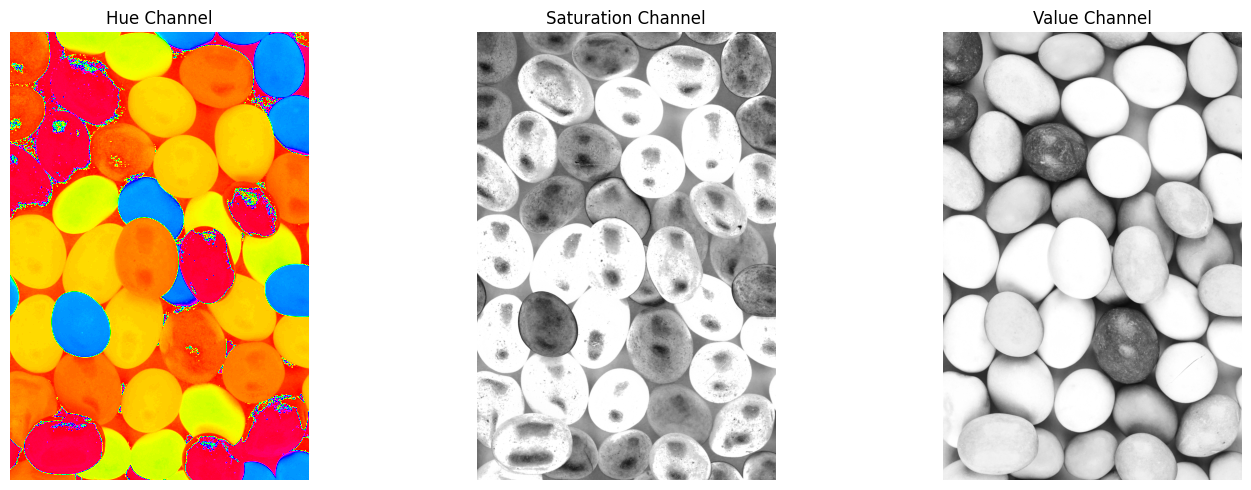

In [39]:
# Step 3: Split the HSV channels
H, S, V = cv2.split(img_hsv)

# Step 4: Display the HSV channels
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Hue Channel")
plt.imshow(H, cmap='hsv')  # Hue displayed using the HSV colormap
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Saturation Channel")
plt.imshow(S, cmap='gray')  # Grayscale for intensity
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Value Channel")
plt.imshow(V, cmap='gray')  # Grayscale for brightness
plt.axis('off')

plt.tight_layout()
plt.show()


- ------------------------------------LAB-----------------------------------

- CV2

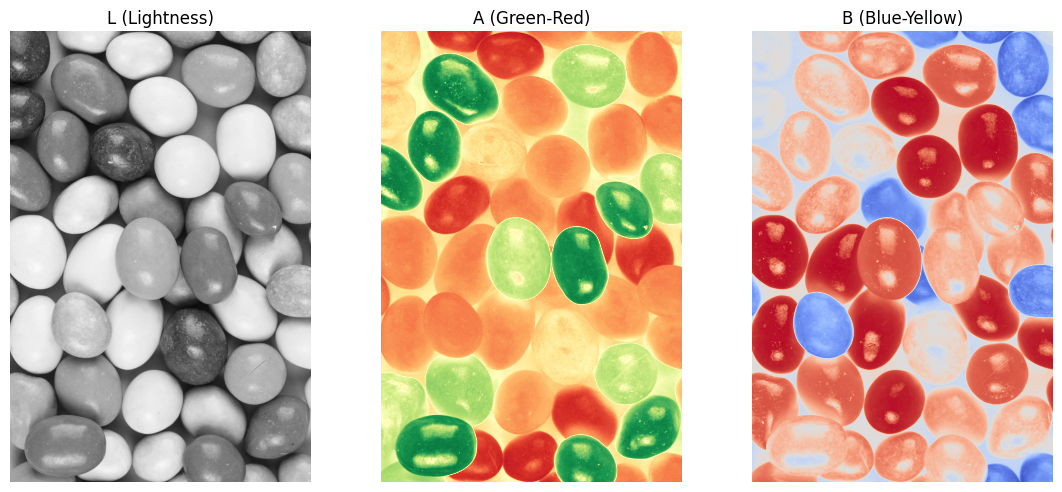

In [33]:
# Convert the image to LAB color space
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# Split the LAB channels
L, A, B = cv2.split(img_lab)

# Display the channels
plt.figure(figsize=(15, 5))


plt.subplot(1, 4, 1)
plt.title("L (Lightness)")
plt.imshow(L, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("A (Green-Red)")
plt.imshow(A, cmap="RdYlGn")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("B (Blue-Yellow)")
plt.imshow(B, cmap="coolwarm")
plt.axis("off")

plt.tight_layout()
plt.show()


- MANUALLY

- -------------------------------GRAY---------------------------------

- CV2

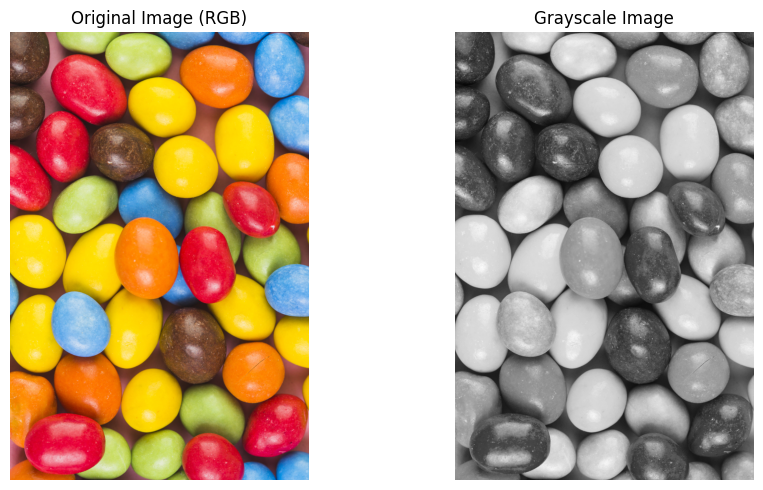

In [34]:
# Convert the image to grayscale using cv2.COLOR_RGB2GRAY
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Display the original image and the grayscale image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image (RGB)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.tight_layout()
plt.show()


- manually


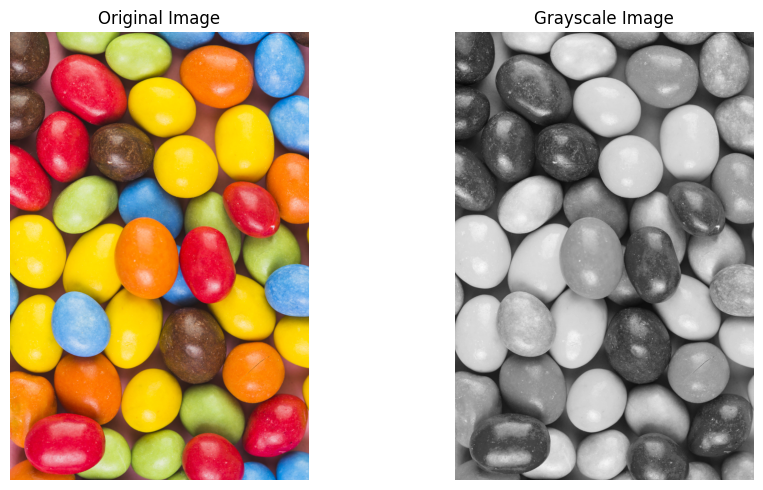

In [ ]:
# Normalize RGB valeeus
R_prime = img_rgb[:, :, 0] / 255
G_prime = img_rgb[:, :, 1] / 255
B_prime = img_rgb[:, :, 2] / 255

# Compute grayscale 
Grayscale = 0.2989 * R_prime + 0.5870 * G_prime + 0.1140 * B_prime

# Display results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grayscale Image")
plt.imshow(Grayscale, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


- --------------------------YCBYCR--------------------

- MANUALLY

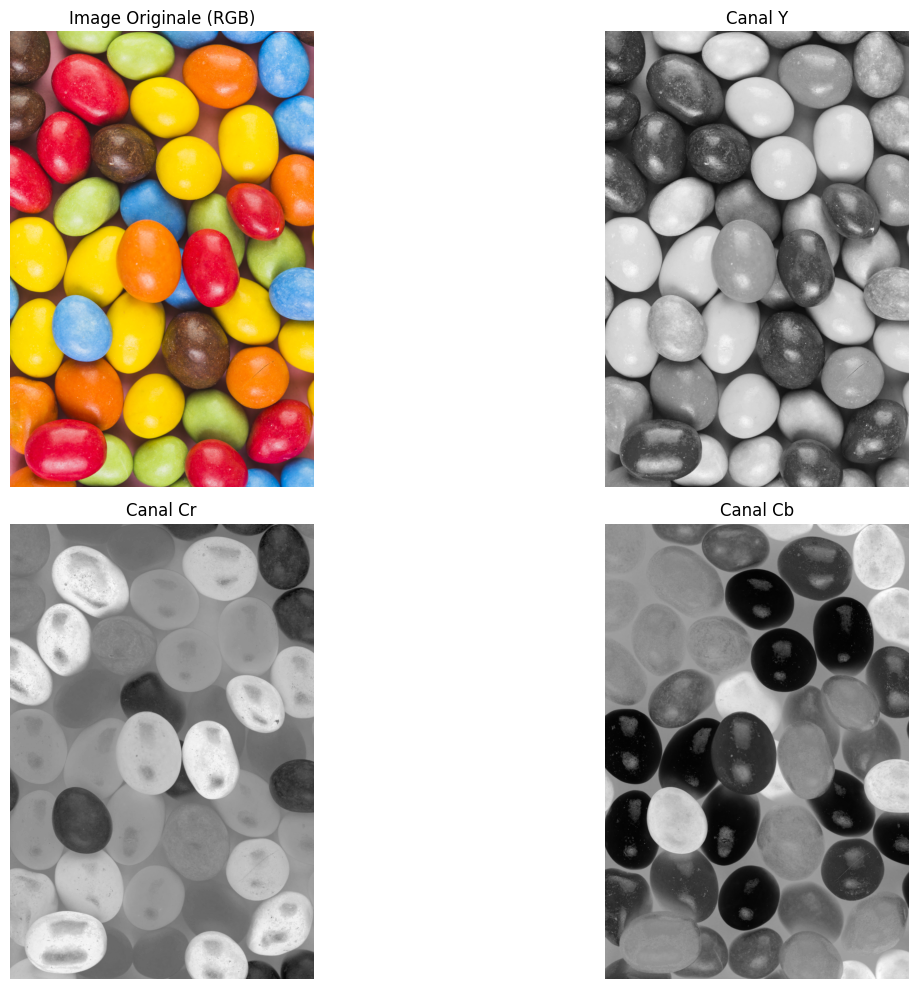

In [55]:
# Normalize RGB valeeus
R = img_rgb[:, :, 0] / 255
G = img_rgb[:, :, 1] / 255
B = img_rgb[:, :, 2] / 255.

# Calculer les canaux Y, Cr, et Cb
Y = 0.299 * R + 0.587 * G + 0.114 * B
Cr = 0.5 * R - 0.418688 * G - 0.081312 * B + 128 
Cb = -0.168736 * R - 0.331264 * G + 0.5 * B + 128 

# Fusionner les canaux Y, Cr, et Cb 
img_ycrcb_manual = cv2.merge([Y, Cr, Cb])

# Afficher les résultats
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.title("Image Originale (RGB)")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Canal Y")
plt.imshow(Y, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Canal Cr")
plt.imshow(Cr, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Canal Cb")
plt.imshow(Cb, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()
